In [1]:
# Cell 1 — Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\anura\Downloads\creditcard.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:", round(df['Class'].mean() * 100, 3), "%")
df.head()

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.173 %


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


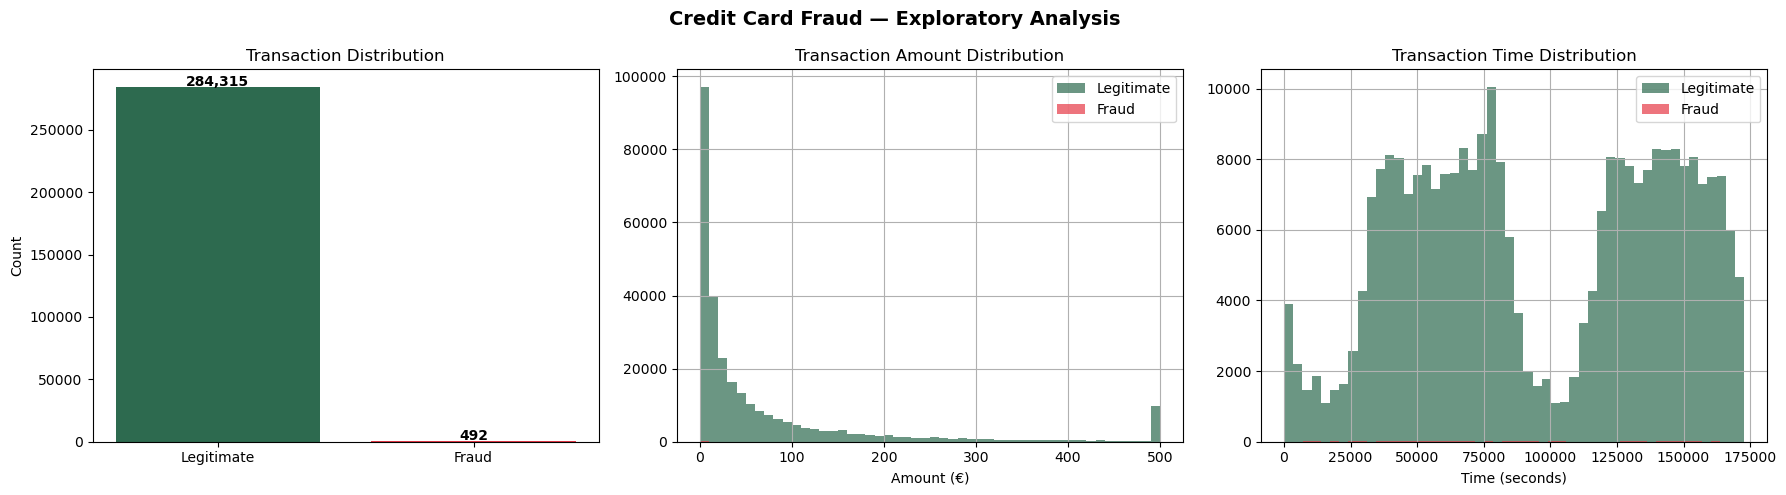

Legitimate transactions — Avg Amount: £ 88.29
Fraud transactions — Avg Amount: £ 122.21
Max fraud amount: £ 2125.87


In [2]:
# Cell 2 — EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Credit Card Fraud — Exploratory Analysis', fontsize=14, fontweight='bold')

# 1. Class Distribution
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, 
            color=['#2d6a4f', '#e63946'])
axes[0].set_title('Transaction Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 2. Amount Distribution by Class
df[df['Class']==0]['Amount'].clip(upper=500).hist(
    bins=50, ax=axes[1], color='#2d6a4f', alpha=0.7, label='Legitimate')
df[df['Class']==1]['Amount'].clip(upper=500).hist(
    bins=50, ax=axes[1], color='#e63946', alpha=0.7, label='Fraud')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount (€)')
axes[1].legend()

# 3. Time Distribution by Class
df[df['Class']==0]['Time'].hist(
    bins=50, ax=axes[2], color='#2d6a4f', alpha=0.7, label='Legitimate')
df[df['Class']==1]['Time'].hist(
    bins=50, ax=axes[2], color='#e63946', alpha=0.7, label='Fraud')
axes[2].set_title('Transaction Time Distribution')
axes[2].set_xlabel('Time (seconds)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Stats
print("Legitimate transactions — Avg Amount: £", round(df[df['Class']==0]['Amount'].mean(), 2))
print("Fraud transactions — Avg Amount: £", round(df[df['Class']==1]['Amount'].mean(), 2))
print("Max fraud amount: £", df[df['Class']==1]['Amount'].max())

In [3]:
# Cell 3 — Preprocessing
# Scale Amount and Time (V1-V28 already scaled from PCA)
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time
df_model = df.drop(['Amount', 'Time'], axis=1)

# Split features and target
X = df_model.drop('Class', axis=1)
y = df_model['Class']

# Train test split — stratified to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nFraud in training:", y_train.sum(), "cases")
print("Fraud in test:", y_test.sum(), "cases")

Training set: (227845, 30)
Test set: (56962, 30)

Fraud in training: 394 cases
Fraud in test: 98 cases


In [4]:
# Cell 4 — Train XGBoost
# scale_pos_weight handles class imbalance
# ratio = legitimate / fraud
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:,1]

print("\n" + "="*45)
print("XGBOOST FRAUD DETECTION RESULTS")
print("="*45)
print(classification_report(y_test, y_pred, 
      target_names=['Legitimate', 'Fraud']))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))

scale_pos_weight: 577.3

XGBOOST FRAUD DETECTION RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.77      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9754


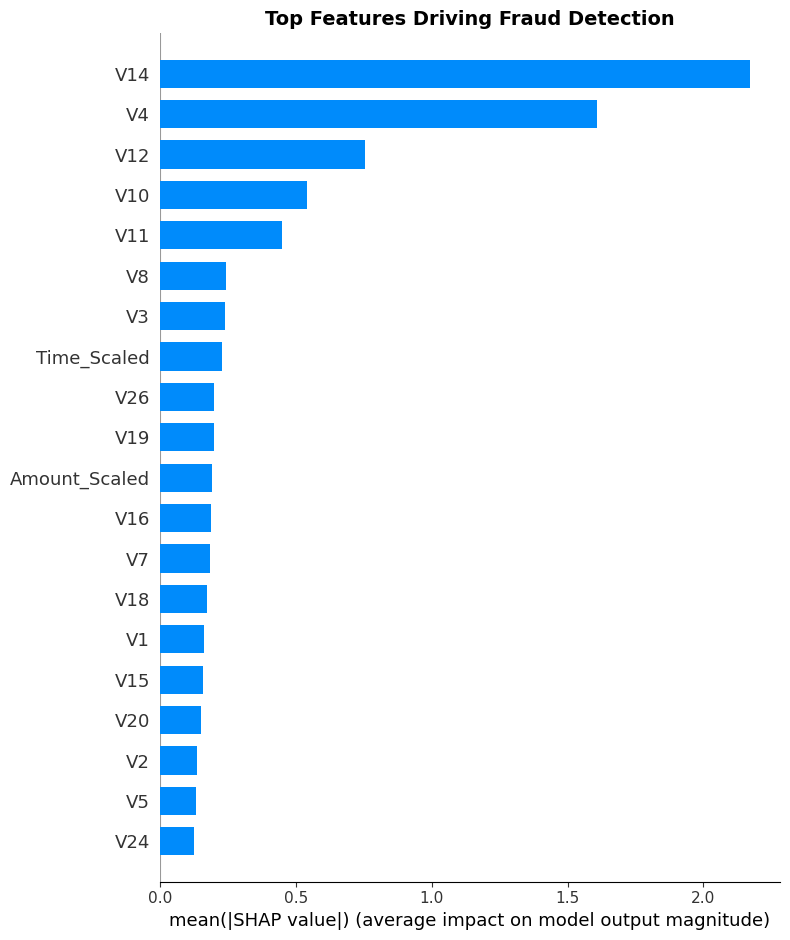

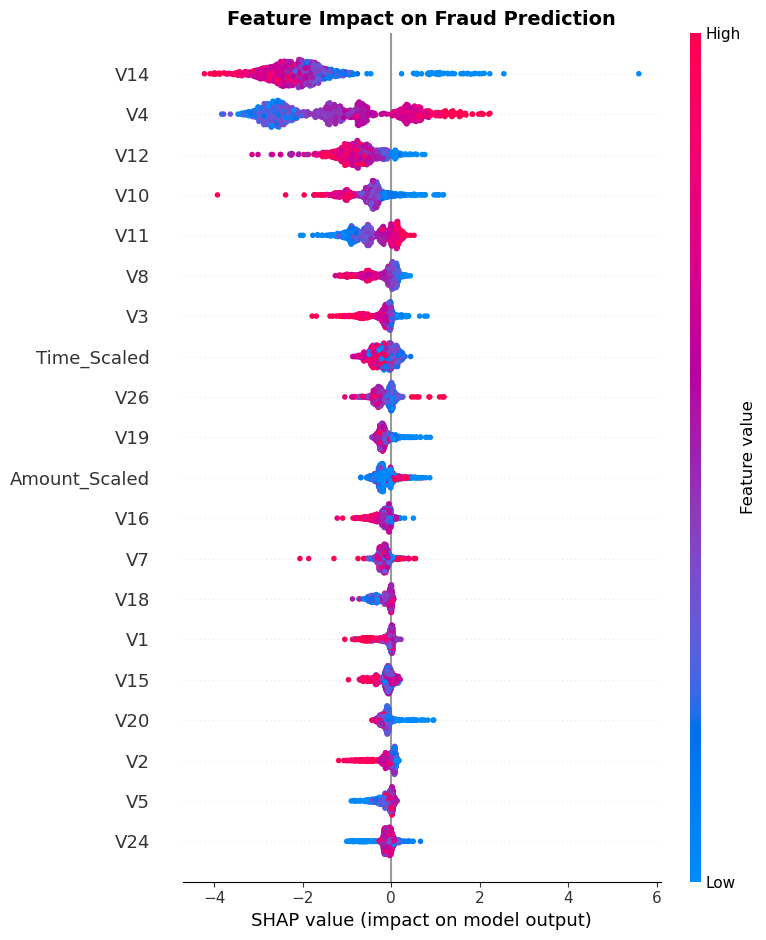

In [5]:
# Cell 5 — SHAP Analysis
explainer = shap.TreeExplainer(xgb_model)
# Use sample of 1000 for speed
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

# Plot 1 — Global Feature Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample,
                  plot_type="bar", show=False)
plt.title('Top Features Driving Fraud Detection', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2 — SHAP Dot Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('Feature Impact on Fraud Prediction',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()